In [9]:
# ----------------------------------------------------------------------------
# Title: Weeks 9 & 10 Assignment - TSA Complaints
# Author: Surenther Selvaraj
# Date: 18 May 2026
# Modified By: Surenther Selvaraj
# ----------------------------------------------------------------------------

### Setup and Data Loading

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings


# Set styling for scannability and professional aesthetic
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# 1. Load datasets
df_airport = pd.read_csv('complaints-by-airport.csv')
df_cat = pd.read_csv('complaints-by-category.csv')
df_geo = pd.read_csv('iata-icao.csv')

# 2. Clean missing values from the complaint datasets
df_airport_clean = df_airport.dropna(subset=['airport'])
df_cat_clean = df_cat.dropna(subset=['airport'])

# 3. Clean the geospatial lookup dataframe safely
df_geo_us = df_geo[df_geo['country_code'] == 'US'].copy()

# Fix: Rename the existing 'airport' column so it doesn't conflict
df_geo_us = df_geo_us.rename(columns={
    'airport': 'airport_full_name', 
    'iata': 'airport'
})

# 4. Merge
df_map_data = pd.merge(df_airport_clean, df_geo_us, on='airport', how='inner')
df_cat_geo = pd.merge(df_cat_clean, df_geo_us, on='airport', how='inner')

print("Merge completed successfully!")
print("Columns in df_map_data:", df_map_data.columns.tolist())

warnings.filterwarnings("ignore")

Merge completed successfully!
Columns in df_map_data: ['pdf_report_date', 'airport', 'year_month', 'count', 'country_code', 'region_name', 'icao', 'airport_full_name', 'latitude', 'longitude']


### VISUAL 1: Spatial Map / Choropleth

In [11]:
# Highlights systemic operational hotspots across US Hubs
fig_spatial = px.scatter_mapbox(
    df_map_data.groupby(['airport', 'latitude', 'longitude'])['count'].sum().reset_index(),
    lat="latitude", lon="longitude", size="count", color="count",
    color_continuous_scale=px.colors.sequential.OrRd, size_max=40, zoom=3,
    mapbox_style="carto-positron", title="US Airport TSA Complaint Hotspots (Systemic Staffing Gaps)"
)
fig_spatial.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig_spatial.show()

### VISUAL 2: Correlation Heatmap 

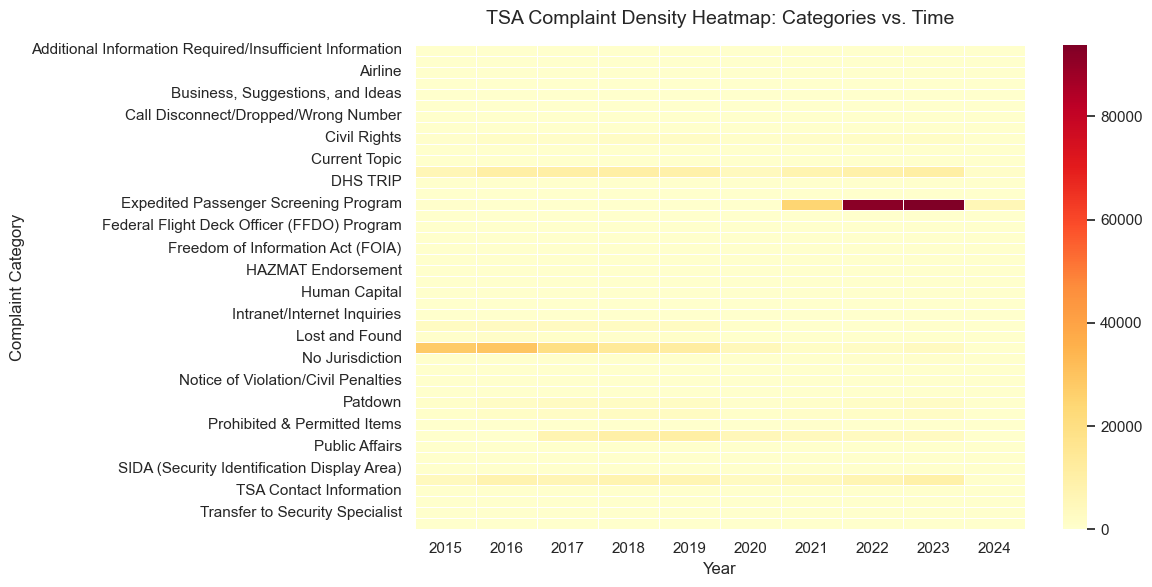

In [ ]:
# Examines historical temporal patterns by category over time
plt.figure(figsize=(12, 6))

# Fix: Create a clean copy and explicitly cast the date format to enable the .dt accessor safely
df_heatmap_data = df_cat_clean.copy()
df_heatmap_data['year_month'] = pd.to_datetime(df_heatmap_data['year_month'], errors='coerce')

# Drop any unparseable dates if they exist
df_heatmap_data = df_heatmap_data.dropna(subset=['year_month'])

# Pivot table using the properly formatted datetime column
pivot_cat = df_heatmap_data.groupby(
    ['clean_cat', df_heatmap_data['year_month'].dt.year]
)['count'].sum().unstack().fillna(0)

# Generate Heatmap
sns.heatmap(pivot_cat, cmap="YlOrRd", annot=False, fmt=".0f", linewidths=.5)
plt.title("TSA Complaint Density Heatmap: Categories vs. Time", pad=15)
plt.ylabel("Complaint Category")
plt.xlabel("Year")
plt.tight_layout()
plt.show()
plt.close()